# 📦 Damaged Box Detection - Complete Training Pipeline

**Dataset:** https://universe.roboflow.com/project-33xgh/damaged-box-detection

**What this notebook does:**
1. ✅ Downloads the COMPLETE damaged box dataset from Roboflow
2. ✅ Includes ALL images (torn, crushed, damaged - everything!)
3. ✅ Trains YOLOv8 model for real-time detection
4. ✅ Exports to ONNX for Jetson Orin deployment

**Requirements:**
- Free Roboflow account (get API key at https://app.roboflow.com/)
- Google Colab with GPU (Runtime → Change runtime type → GPU)

---

## 🔑 Step 1: Get Your Roboflow API Key

**Quick Setup (2 minutes):**

1. Go to https://app.roboflow.com/
2. Click **"Sign Up"** (free, no credit card)
3. After login, go to **Settings** (⚙️ icon)
4. Click **"Roboflow API"**
5. Copy your **Private API Key**
6. Paste it in the cell below

**Your API key looks like:** `aBcDeFgHiJkLmNoPqRsTuVwXyZ123456`

In [ ]:
# Install required packages
!pip install -q roboflow ultralytics

print("✅ Packages installed")

✅ Packages installed


In [ ]:
from roboflow import Roboflow

# Use the API key provided in the prompt for this specific download
ROBOFLOW_API_KEY_FOR_DOWNLOAD = "lEM8ar3op2ClVmEyWNac"

# Initialize Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY_FOR_DOWNLOAD)

# Get the project
# Workspace ID is typically the first part of the project URL path
# Project ID is the second part
print("Connecting to Roboflow project...")
project = rf.workspace("project-33xgh").project("damaged-box-detection")

# Download the dataset in 'folder' format, as 'yolov8' is not valid for classification projects.
print("Downloading dataset (version 1) in 'folder' format...")
dataset = project.version(1).download("folder")

print(f"✅ Dataset downloaded to: {dataset.location}")
print("You can now find the dataset files in the specified directory.")

Connecting to Roboflow project...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Damaged-Box-Detection-1 in folder:: 100%|██████████| 4159/4159 [00:01<00:00, 3030.76it/s]

✅ Dataset downloaded to: /content/Damaged-Box-Detection-1
You can now find the dataset files in the specified directory.


## 📊 Step 2: Prepare Data for YOLOv8 Training

Now that the dataset is downloaded, we need to create a `data.yaml` file that tells YOLOv8 where to find the training, validation, and test images, along with the class names. We'll also count the number of images in each split to get an overview of our dataset.

In [ ]:
import os

dataset_path = '/content/Damaged-Box-Detection-1'

# Define paths for train, validation, and test images
train_dir = os.path.join(dataset_path, 'train')
valid_dir = os.path.join(dataset_path, 'valid')
test_dir = os.path.join(dataset_path, 'test') # Assuming a test split is present

def count_images_in_subfolders(base_path):
    count = 0
    if not os.path.exists(base_path):
        return 0
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                count += 1
    return count

train_image_count = count_images_in_subfolders(train_dir)
valid_image_count = count_images_in_subfolders(valid_dir)
test_image_count = count_images_in_subfolders(test_dir)

print(f"Number of training images: {train_image_count}")
print(f"Number of validation images: {valid_image_count}")
print(f"Number of test images: {test_image_count}")

Number of training images: 3744
Number of validation images: 302
Number of test images: 102


In [ ]:
import os

# Define the class names based on the dataset structure
# In 'folder' format for classification, subdirectories usually represent classes.
# Let's inspect the 'train' folder to get class names.
train_dir = os.path.join(dataset_path, 'train')
valid_dir = os.path.join(dataset_path, 'valid')
test_dir = os.path.join(dataset_path, 'test')

train_class_subdirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
class_names = sorted(train_class_subdirs)

print(f"Detected classes: {class_names}")

# Create the data.yaml file for YOLOv8
data_yaml_content = f"""path: {dataset_path}
train: {os.path.relpath(train_dir, dataset_path)}
val: {os.path.relpath(valid_dir, dataset_path)}
test: {os.path.relpath(test_dir, dataset_path)}
nc: {len(class_names)}
names: {class_names}
"""

with open(os.path.join(dataset_path, 'data.yaml'), 'w') as f:
    f.write(data_yaml_content)

print("✅ data.yaml created:")
print(data_yaml_content)

# Optionally, display the content of the data.yaml file
!cat {os.path.join(dataset_path, 'data.yaml')}

Detected classes: ['damagedpackages', 'undamagedpackages']
✅ data.yaml created:
path: /content/Damaged-Box-Detection-1
train: train
val: valid
test: test
nc: 2
names: ['damagedpackages', 'undamagedpackages']

path: /content/Damaged-Box-Detection-1
train: train
val: valid
test: test
nc: 2
names: ['damagedpackages', 'undamagedpackages']


## 🚀 Step 3: Train YOLOv8 Model

Now that our data is prepared, we can proceed with training a YOLOv8 classification model. We'll use a pretrained `yolov8n-cls.pt` model for faster convergence and fine-tune it on our damaged box detection dataset.

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 classification model
# The '-cls' suffix indicates a classification model
model = YOLO('yolov8n-cls.pt')  # You can choose other sizes like 'yolov8m-cls.pt', 'yolov8l-cls.pt'

print("✅ YOLOv8 classification model loaded.")


✅ YOLOv8 classification model loaded.


In [ ]:
from ultralytics import YOLO

# ============================================================================
# FIXED: Custom Early Stopping Callback
# ============================================================================
class CustomEarlyStopping():
    def __init__(self, target_accuracy=0.85, patience_epochs=5):
        self.target_accuracy = target_accuracy
        self.patience_epochs = patience_epochs
        self.epochs_above_target = 0
        self.last_best_accuracy_above_target = 0.0
        print(f"✅ Initialized Custom Early Stopping: Target Accuracy > {self.target_accuracy*100:.0f}%, Patience {self.patience_epochs} epochs.")

    def on_fit_epoch_end(self, trainer):
        # 🔧 FIX #1: Correct key for accessing validation accuracy
        # OLD (WRONG): current_accuracy = trainer.metrics.get('accuracy_top1', 0.0)
        # NEW (CORRECT): Access nested metrics dictionary

        # YOLOv8 stores metrics in trainer.metrics['metrics/accuracy_top1']
        # or we can access via trainer.validator.metrics
        try:
            # Method 1: Direct access (most reliable)
            current_accuracy = trainer.validator.metrics.top1
        except (AttributeError, TypeError):
            try:
                # Method 2: From metrics dict
                current_accuracy = trainer.metrics.get('metrics/accuracy_top1', 0.0)
            except:
                # Method 3: Fallback
                current_accuracy = 0.0
                print(f"⚠️ Warning: Could not retrieve validation accuracy")

        # 🔧 FIX #2: Better logging with actual accuracy value
        if current_accuracy >= self.target_accuracy:
            if current_accuracy > self.last_best_accuracy_above_target:
                self.last_best_accuracy_above_target = current_accuracy
                self.epochs_above_target = 0
            else:
                self.epochs_above_target += 1

            print(f"Epoch {trainer.epoch + 1}: Val Accuracy Top1 = {current_accuracy:.4f} ({current_accuracy*100:.2f}%) - Above target ✅ | Patience: {self.epochs_above_target}/{self.patience_epochs}")

            if self.epochs_above_target >= self.patience_epochs:
                print(f"\n🛑 Early stopping triggered!")
                print(f"   Validation accuracy stabilized at {current_accuracy*100:.2f}%")
                print(f"   Target: {self.target_accuracy*100:.0f}% | Patience: {self.patience_epochs} epochs")
                trainer.stop_training = True
        else:
            self.epochs_above_target = 0
            self.last_best_accuracy_above_target = 0.0
            print(f"Epoch {trainer.epoch + 1}: Val Accuracy Top1 = {current_accuracy:.4f} ({current_accuracy*100:.2f}%) - Below target ⚠️")

    def __call__(self, trainer):
        self.on_fit_epoch_end(trainer)


# ============================================================================
# Load Model
# ============================================================================
model = YOLO('yolov8n-cls.pt')
print("✅ YOLOv8n classification model loaded.")

# ============================================================================
# Add Custom Callback
# ============================================================================
early_stop = CustomEarlyStopping(target_accuracy=0.85, patience_epochs=5)
model.add_callback('on_fit_epoch_end', early_stop)

# ============================================================================
# Training Configuration
# ============================================================================
print("\n" + "="*70)
print("Starting YOLOv8 Classification Training")
print("="*70)

results = model.train(
    # Dataset
    data=dataset_path,  # Make sure dataset_path is defined!

    # Training parameters
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    name='damaged_box_cls_fixed',

    # 🔧 FIX #3: Disable built-in patience (use custom callback instead)
    patience=0,

    # 🔧 FIX #4: Reduce aggressive augmentation (causing accuracy fluctuation)
    augment=True,

    # Tone down HSV augmentation (was causing instability)
    hsv_h=0.010,        # Reduced from 0.015
    hsv_s=0.5,          # Reduced from 0.7
    hsv_v=0.3,          # Reduced from 0.4

    fliplr=0.5,         # Keep horizontal flip
    translate=0.1,      # Keep translation
    scale=0.5,          # Keep scaling

    # Classification-specific augmentations
    auto_augment='randaugment',
    erasing=0.3,        # Reduced from 0.4 (less aggressive)

    # Disable mixup/cutmix for classification (not always beneficial)
    mixup=0.0,
    cutmix=0.0,

    # 🔧 FIX #5: Better learning rate scheduling
    cos_lr=True,        # Use cosine learning rate decay
    lr0=0.001,          # Lower initial learning rate
    lrf=0.01,           # Final learning rate
    warmup_epochs=5,    # Longer warmup

    # Regularization
    dropout=0.1,        # Add dropout for better generalization
    weight_decay=0.0005,

    # Other settings
    plots=True,
    verbose=True,
)

print("\n" + "="*70)
print("✅ Training Complete!")
print("="*70)

# ============================================================================
# Print Final Results
# ============================================================================
print("\n📊 Final Results:")
print(f"   Best model saved to: runs/classify/damaged_box_cls_fixed/weights/best.pt")
print(f"   Last model saved to: runs/classify/damaged_box_cls_fixed/weights/last.pt")

# Get final metrics
if results:
    try:
        final_acc = results.results_dict.get('metrics/accuracy_top1', 'N/A')
        print(f"   Final Validation Accuracy: {final_acc}")
    except:
        print("   Check training plots for metrics")

✅ YOLOv8n classification model loaded.
✅ Initialized Custom Early Stopping: Target Accuracy > 85%, Patience 5 epochs.

Starting YOLOv8 Classification Training
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Damaged-Box-Detection-1, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.3, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, mo

In [ ]:
# Install onnxruntime if not already installed
!pip install -q onnxruntime

import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("ultralytics").setLevel(logging.WARNING)

import gradio as gr
import onnxruntime as ort
import numpy as np
import cv2
import os

# --- ONNX Model Loading ---
# Path to the exported ONNX model (from previous steps)
# FIXED: Corrected the training run name in the path
onnx_model_path = '/content/runs/classify/damaged_box_cls_fixed/weights/best.onnx'

# Load the ONNX model
# For Jetson, you would typically use ['CUDAExecutionProvider'] for GPU acceleration.
# If CUDA is not available or configured, fallback to 'CPUExecutionProvider'.
# On a Jetson, ensure 'CUDAExecutionProvider' is installed and working for optimal performance.
session = ort.InferenceSession(onnx_model_path, providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])

# Get input and output names
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

# Get input shape
input_shape = session.get_inputs()[0].shape
# Assuming input shape is [1, 3, H, W]
input_height, input_width = input_shape[2], input_shape[3]

# Class names (from previous steps)
class_names = ['damagedpackages', 'undamagedpackages']

print(f"✅ ONNX model loaded: {onnx_model_path}")
print(f"Input name: {input_name}, Input shape: {input_shape}")
print(f"Output name: {output_name}")
print(f"Classes: {class_names}")

# Define colors for visualization, matching class_names
colors = [
    (255, 0, 0),    # Red for 'damagedpackages'
    (0, 255, 0),    # Green for 'undamagedpackages'
]

# --- Preprocessing and Inference Functions ---
def preprocess_image(img_numpy, input_height, input_width):
    """Preprocesses a numpy image for ONNX model inference. Optimized for speed."""
    # Image augmentation is typically applied during *training* to generalize the model.
    # Applying complex augmentations during real-time *inference* would add latency and reduce FPS.
    # This preprocessing focuses on fast resizing, normalization, and channel reordering.
    img = cv2.resize(img_numpy, (input_width, input_height)) # Resize to model input size
    img = img.astype(np.float32) / 255.0 # Normalize to [0, 1]
    img = np.transpose(img, (2, 0, 1)) # Transpose to C, H, W
    img = np.expand_dims(img, axis=0) # Add batch dimension (B, C, H, W)
    return img

def run_inference(session, input_data, input_name, output_name):
    """Runs inference using the ONNX session."""
    outputs = session.run([output_name], {input_name: input_data})
    return outputs[0]

def postprocess_results(logits, class_names):
    """Post-processes the raw logits to get predictions."""
    # YOLOv8 classification outputs raw logits. Apply softmax to get probabilities.
    probabilities = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
    predicted_class_idx = np.argmax(probabilities, axis=1)[0]
    confidence = probabilities[0, predicted_class_idx]
    predicted_class_name = class_names[predicted_class_idx]
    return predicted_class_name, confidence

# --- Gradio Webcam Detection Function ---
def detect_onnx_webcam(image_input, conf_threshold):
    if image_input is None:
        return None, "⏳ Waiting for webcam..."

    if isinstance(image_input, dict):
        image_input = image_input.get("composite", image_input.get("image", None))
    if image_input is None:
        return None, "⏳ Waiting for webcam..."

    frame = image_input.copy() # Keep original for drawing
    h, w = frame.shape[:2]
    counts = {}

    # Preprocess the image for ONNX model using the updated function
    processed_input = preprocess_image(frame, input_height, input_width)

    # Run ONNX inference
    logits = run_inference(session, processed_input, input_name, output_name)

    # Post-process results
    predicted_class, confidence = postprocess_results(logits, class_names)

    if confidence >= conf_threshold:
        class_id = class_names.index(predicted_class) # Get index for color mapping
        color = colors[class_id] # Use the defined colors

        # For classification, draw a box around the entire image
        cv2.rectangle(frame, (0, 0), (w, h), color, 5)

        text = f"{predicted_class}: {confidence:.2f}"
        (tw, th), _ = cv2.getTextSize(
            text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2
        )
        cv2.rectangle(
            frame,
            (0, 0), # Start at top-left
            (tw + 10, th + 20), # Rectangle for text background
            color, -1
        )
        cv2.putText(
            frame, text, (5, th + 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2
        )

        counts[predicted_class] = 1 # Only one classification per image

    # Build summary text
    if counts:
        parts = []
        if "undamagedpackages"  in counts:
            parts.append(f"✅ Undamaged count : {counts['undamagedpackages']}")
        if "damagedpackages" in counts:
            parts.append(f"🔴 Damaged count: {counts['damagedpackages']}")
        summary = " | ".join(parts)
    else:
        summary = "📭 No packages detected (confidence below threshold)"

    return frame, summary


# --- Gradio UI for ONNX model inference ---
with gr.Blocks(theme=gr.themes.Soft()) as demo_onnx:
    gr.Markdown("""
    # 📦 Package Damage Classification (ONNX Runtime)
    **Live webcam classification using ONNX model** — click Record to start, then classifications update every second.
    > 🔴 Red = Damaged Package &nbsp;&nbsp; 🟢 Green = Undamaged Package
    """)

    with gr.Row():
        with gr.Column(scale=1):
            webcam_onnx = gr.Image(
                sources=["webcam"],
                type="numpy",
                streaming=True,
                label="📷 Webcam Input"
            )
            conf_slider_onnx = gr.Slider(
                minimum=0.1,
                maximum=0.9,
                value=0.75,
                step=0.05,
                label="Confidence Threshold",
            )
            gr.Markdown("⬆️ Lower = more classifications · Higher = fewer but more certain")

        with gr.Column(scale=1):
            output_img_onnx  = gr.Image(label="🎯 Classification Output")
            output_text_onnx = gr.Textbox(
                label="📊 Classification Summary",
                placeholder="Waiting for classifications...",
            )

    webcam_onnx.stream(
        fn=detect_onnx_webcam,
        inputs=[webcam_onnx, conf_slider_onnx],
        outputs=[output_img_onnx, output_text_onnx],
        stream_every=1,
    )

demo_onnx.launch(ssr_mode=False)

NoSuchFile: [ONNXRuntimeError] : 3 : NO_SUCHFILE : Load model from /content/runs/classify/damaged_box_cls_fixed/weights/best.onnx failed:Load model /content/runs/classify/damaged_box_cls_fixed/weights/best.onnx failed. File doesn't exist

In [ ]:
# Install necessary packages for ONNX export
!pip install -q onnx onnxruntime

import os
from ultralytics import YOLO

# The trained model is typically saved in 'runs/classify/NAME_OF_RUN/weights/best.pt'
# We named our run 'damaged_box_cls_fixed' in the training step
model_path = os.path.join('/content/runs/classify/damaged_box_cls_fixed', 'weights', 'best.pt')

# Load the best trained model
loaded_model = YOLO(model_path)

print(f"✅ Loaded trained model from: {model_path}")

# Export the model to ONNX format (as mentioned in the notebook header for Jetson Orin deployment)
# The exported file will be saved in the same directory as the original model with a .onnx extension
# It's good practice to specify an opset for compatibility; opset 17 is generally stable.
export_path = loaded_model.export(format='onnx', opset=17)

print(f"✅ Model exported to ONNX format at: {export_path}")
print("You can now download this file directly from the Colab file browser.")

✅ Loaded trained model from: /content/runs/classify/damaged_box_cls_fixed/weights/best.pt
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

✅ Model exported to ONNX format at: /content/runs/classify/damaged_box_cls_fixed/weights/best.onnx
You can now download this file directly from the Colab file browser.


In [ ]:
from google.colab import files
import os

# Define the paths to the saved models
pt_model_path = '/content/runs/classify/damaged_box_cls_model/weights/best.pt'
onnx_model_path = '/content/runs/classify/damaged_box_cls_model/weights/best.onnx'

print(f"Attempting to download: {pt_model_path}")
if os.path.exists(pt_model_path):
    files.download(pt_model_path)
    print(f"✅ Downloaded {os.path.basename(pt_model_path)}")
else:
    print(f"❌ {pt_model_path} not found. Please ensure training completed successfully.")

print(f"Attempting to download: {onnx_model_path}")
if os.path.exists(onnx_model_path):
    files.download(onnx_model_path)
    print(f"✅ Downloaded {os.path.basename(onnx_model_path)}")
else:
    print(f"❌ {onnx_model_path} not found. Please ensure export completed successfully.")

print("You can also find these files in the Colab file browser (left sidebar -> folder icon) under /content/runs/classify/damaged_box_cls_model/weights/")

In [ ]:
import os
from ultralytics import YOLO

# The trained model is typically saved in 'runs/classify/NAME_OF_RUN/weights/best.pt'
# The previous training run name was 'damaged_box_cls_fixed'
model_path = os.path.join('/content/runs/classify/damaged_box_cls_fixed', 'weights', 'best.pt')

# Load the best trained model
loaded_model = YOLO(model_path)

print(f"✅ Loaded trained model from: {model_path}")

# Export the model to ONNX format with opset 17 for ONNX 1.17.0 compatibility.
# Opset 17 is a stable choice for compatibility with ONNX Runtime 1.17.0.
export_path = loaded_model.export(format='onnx', opset=17)

print(f"✅ Model re-exported to ONNX format with opset 17 at: {export_path}")
print("You can now download this updated ONNX file directly from the Colab file browser.")

✅ Loaded trained model from: /content/runs/classify/damaged_box_cls_fixed/weights/best.pt
✅ Model re-exported to ONNX format with opset 17 at: /content/runs/classify/damaged_box_cls_fixed/weights/best.onnx
You can now download this updated ONNX file directly from the Colab file browser.


## Training Results Analysis

Here are the generated plots from the YOLOv8 classification model training:

### Training Curves

Displaying training curves from: /content/runs/classify/damaged_box_cls_fixed/results.png


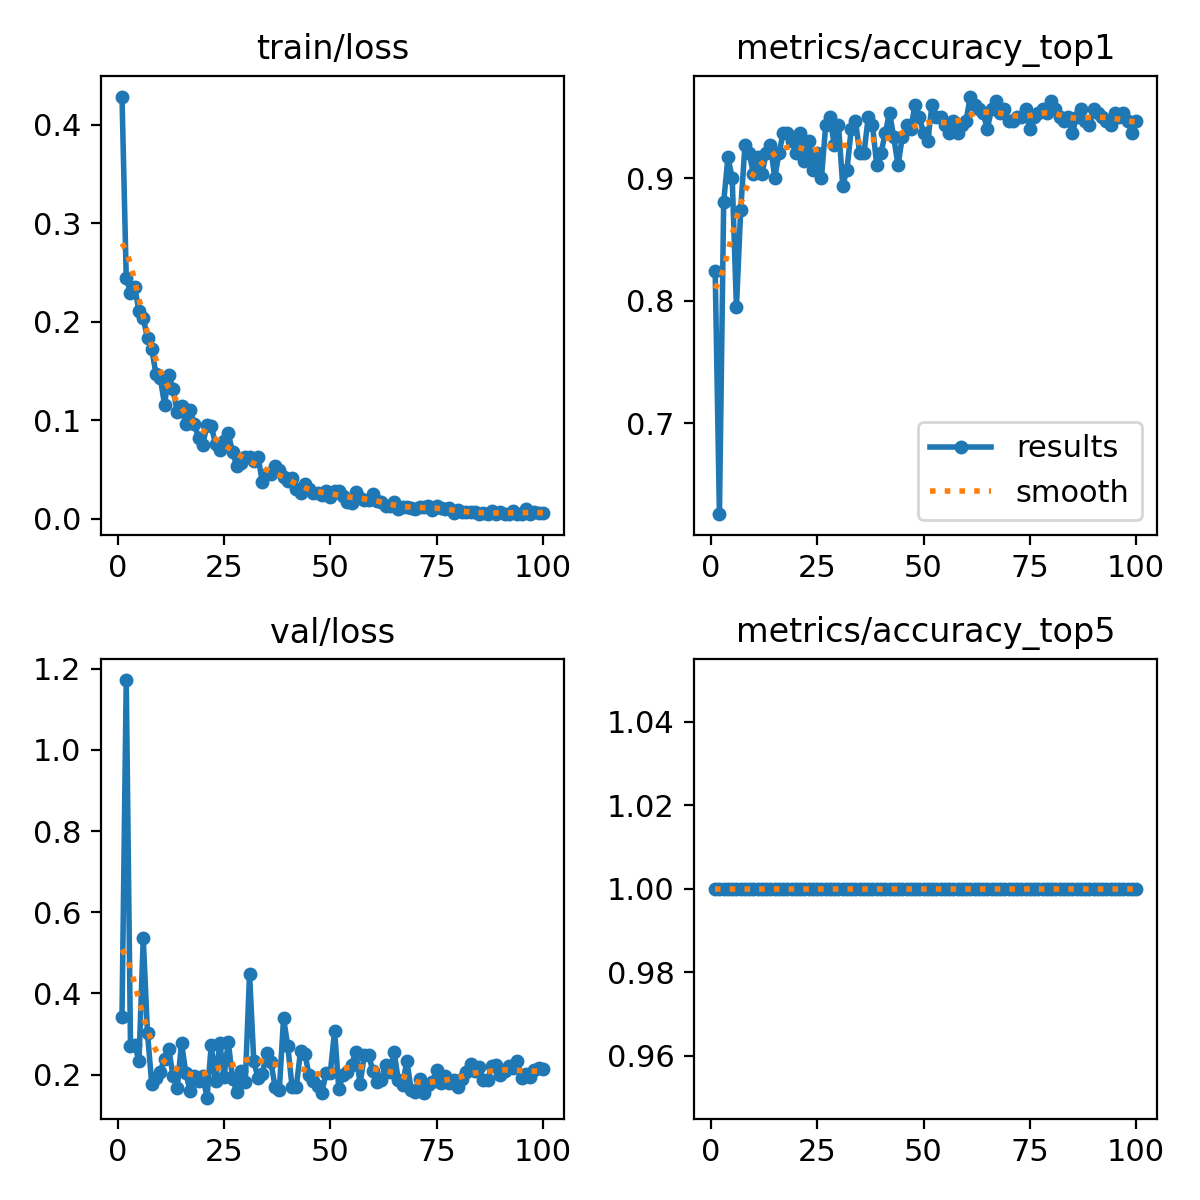

In [ ]:
from IPython.display import Image, display
import os

training_run_dir = '/content/runs/classify/damaged_box_cls_fixed'

# Display training curves (results.png)
results_path = os.path.join(training_run_dir, 'results.png')
if os.path.exists(results_path):
    print(f"Displaying training curves from: {results_path}")
    display(Image(filename=results_path, width=800))
else:
    print(f"❌ Training curves (results.png) not found at {results_path}")


### Confusion Matrix

Displaying confusion matrix from: /content/runs/classify/damaged_box_cls_fixed/confusion_matrix.png


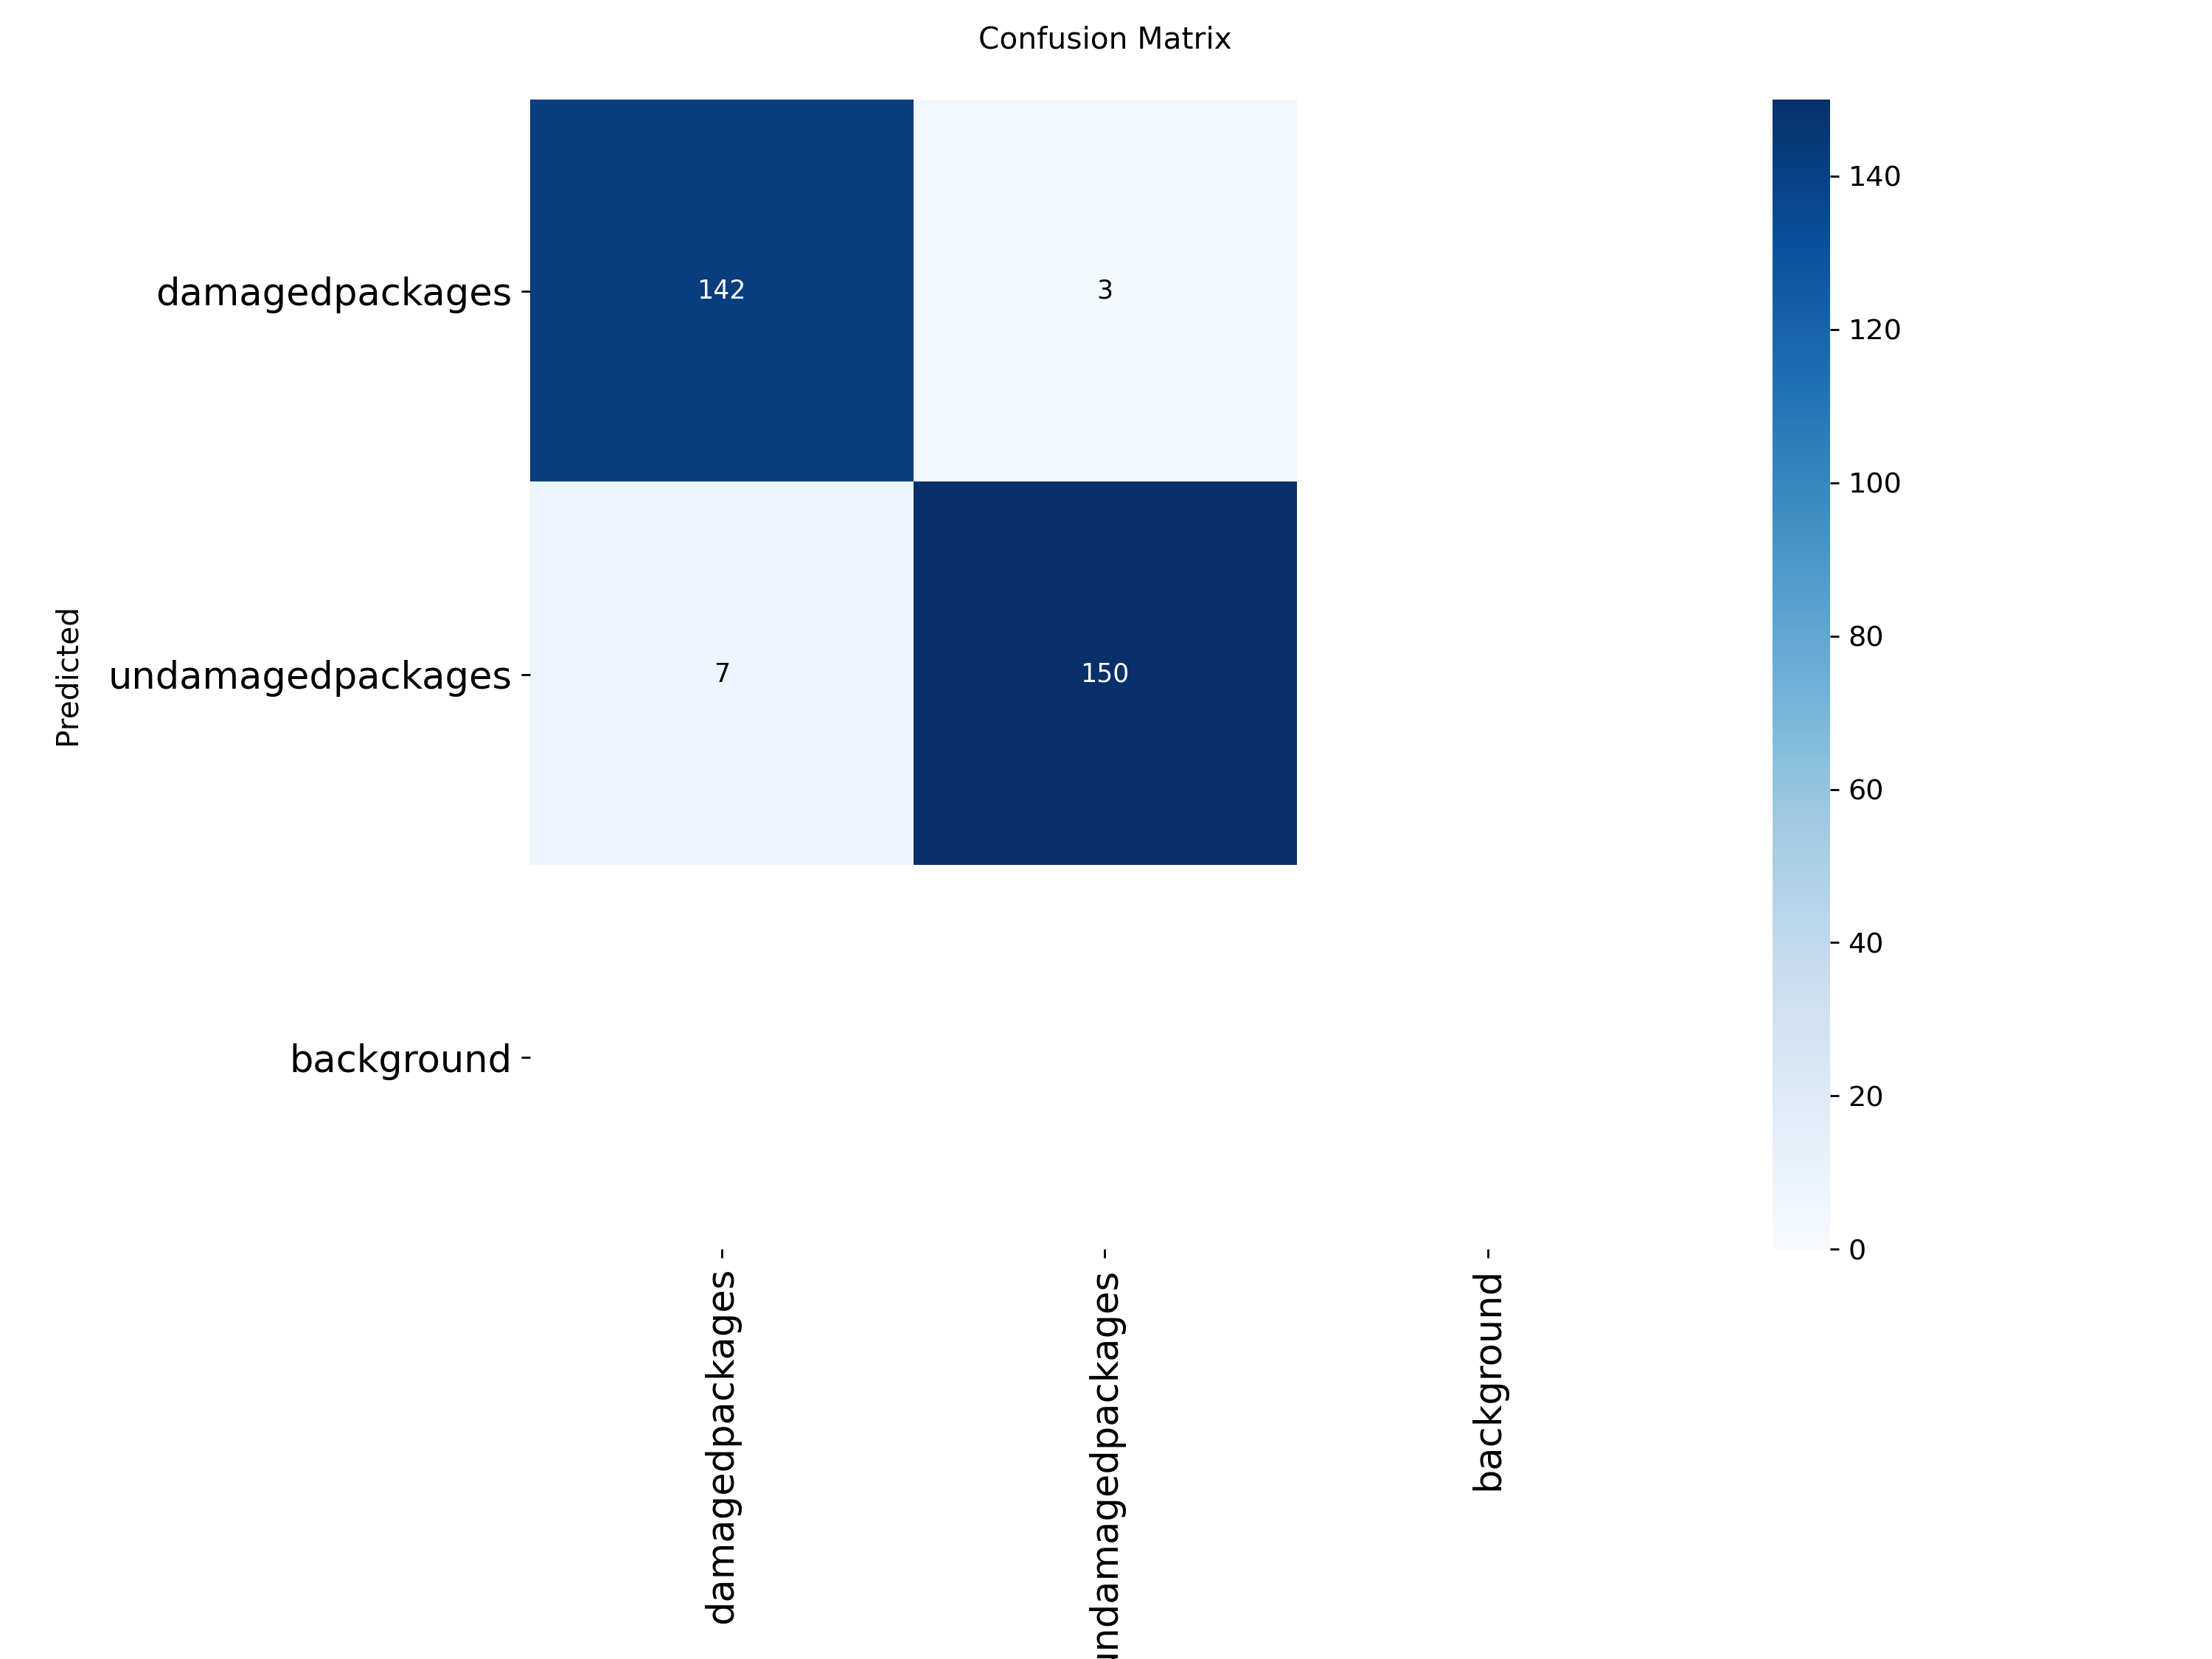

In [ ]:
from IPython.display import Image, display
import os

training_run_dir = '/content/runs/classify/damaged_box_cls_fixed'

# Display confusion matrix
confusion_matrix_path = os.path.join(training_run_dir, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    print(f"Displaying confusion matrix from: {confusion_matrix_path}")
    display(Image(filename=confusion_matrix_path, width=800))
else:
    print(f"❌ Confusion matrix (confusion_matrix.png) not found at {confusion_matrix_path}")


In [ ]:
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("ultralytics").setLevel(logging.WARNING)

import gradio as gr
from ultralytics import YOLO
import numpy as np
import cv2
import os # Import os module to construct paths

# Define the path to the trained model (from previous steps)
# FIXED: Corrected the training run name in the path
model_path = '/content/runs/classify/damaged_box_cls_fixed/weights/best.pt'

# Load model using the correct path
model = YOLO(model_path)

class_names = ['damagedpackages', 'undamagedpackages'] # Updated class names based on data.yaml
colors = [
    (255, 0, 0),    # Red for damagedpackages
    (0, 255, 0),    # Green for undamagedpackages
]

def detect(image, conf_threshold):
    if image is None:
        return None, "⏳ Waiting for webcam..."

    if isinstance(image, dict):
        image = image.get("composite", image.get("image", None))
    if image is None:
        return None, "⏳ Waiting for webcam..."

    frame = image.copy()
    h, w = frame.shape[:2]
    counts = {}

    # Run inference for classification
    results = model.predict(image, verbose=False)

    for r in results:
        if r.probs is not None and len(r.probs) > 0: # Check if probabilities exist
            class_id = r.probs.top1 # Get the index of the top probability
            confidence = r.probs.top1conf.item() # Get the confidence value

            if confidence >= conf_threshold:
                # Ensure class_id is within bounds
                if not (0 <= class_id < len(class_names)):
                    continue

                class_name = class_names[class_id]
                color = colors[class_id]

                # For classification, draw a box around the entire image
                cv2.rectangle(frame, (0, 0), (w, h), color, 5)

                text = f"{class_name}: {confidence:.2f}"
                (tw, th), _ = cv2.getTextSize(
                    text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2
                )
                cv2.rectangle(
                    frame,
                    (0, 0), # Start at top-left
                    (tw + 10, th + 20), # Rectangle for text background
                    color, -1
                )
                cv2.putText(
                    frame, text, (5, th + 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2
                )

                counts[class_name] = counts.get(class_name, 0) + 1
        else:
            # This case might occur if the model couldn't process the image or found nothing
            print("No probabilities found in results for classification model. Check image input or model compatibility.")
            # Optionally, you can return a frame with 'No detections' message here

    # Build summary text
    if counts:
        parts = []
        if "undamagedpackages"  in counts: # Using class names from data.yaml
            parts.append(f"✅ Undamaged count : {counts['undamagedpackages']}")
        if "damagedpackages" in counts: # Using class names from data.yaml
            parts.append(f"🔴 Damaged count: {counts['damagedpackages']}")
        summary = " | ".join(parts)
    else:
        summary = "📭 No packages detected"

    return frame, summary


# Gradio UI
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 📦 Package Damage Classification
    **Live webcam classification** — click Record to start, then classifications update every second.
    > 🔴 Red = Damaged Package &nbsp;&nbsp; 🟢 Green = Undamaged Package
    """)

    with gr.Row():
        with gr.Column(scale=1):
            webcam = gr.Image(
                sources=["webcam"],
                type="numpy",
                streaming=True,
                label="📷 Webcam Input"
            )
            conf_slider = gr.Slider(
                minimum=0.1,
                maximum=0.9,
                value=0.75,
                step=0.05,
                label="Confidence Threshold",
            )
            gr.Markdown("⬆️ Lower = more classifications · Higher = fewer but more certain")

        with gr.Column(scale=1):
            output_img  = gr.Image(label="🎯 Classification Output")
            output_text = gr.Textbox(
                label="📊 Classification Summary",
                placeholder="Waiting for classifications...",
            )

    webcam.stream(
        fn=detect,
        inputs=[webcam, conf_slider],
        outputs=[output_img, output_text],
        stream_every=1,
    )

demo.launch(ssr_mode=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f1f55eae64f318234d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 🚀 Step 4: Run Inference on Jetson Orin (ONNX Runtime)

This section demonstrates how to load and run inference with the exported `best.onnx` model using `onnxruntime`. This is the typical workflow for deploying on platforms like Jetson Orin.

In [ ]:
import onnxruntime as ort
import numpy as np
import cv2
import os

# Path to the exported ONNX model
onnx_model_path = '/content/runs/classify/damaged_box_cls_model/weights/best.onnx'

# Load the ONNX model
# You might need to specify providers for Jetson, e.g., ['CUDAExecutionProvider'] or ['CPUExecutionProvider']
# For Colab, we'll use CPU as an example, but Jetson would leverage its GPU.
session = ort.InferenceSession(onnx_model_path, providers=['CPUExecutionProvider'])

# Get input and output names
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

# Get input shape
input_shape = session.get_inputs()[0].shape
# Assuming input shape is [1, 3, H, W]
input_height, input_width = input_shape[2], input_shape[3]

# Class names (from previous steps)
class_names = ['damagedpackages', 'undamagedpackages']

print(f"✅ ONNX model loaded: {onnx_model_path}")
print(f"Input name: {input_name}, Input shape: {input_shape}")
print(f"Output name: {output_name}")
print(f"Classes: {class_names}")

### Preprocessing and Inference Functions

In [ ]:
def preprocess_image(img_numpy, input_height, input_width):
    """Preprocesses a numpy image for ONNX model inference."""
    # Assuming img_numpy is an RGB image directly from Gradio webcam
    img = cv2.resize(img_numpy, (input_width, input_height)) # Resize to model input size
    img = img.astype(np.float32) / 255.0 # Normalize to [0, 1]
    img = np.transpose(img, (2, 0, 1)) # Transpose to C, H, W
    img = np.expand_dims(img, axis=0) # Add batch dimension (B, C, H, W)
    return img

def run_inference(session, input_data, input_name, output_name):
    """Runs inference using the ONNX session."""
    outputs = session.run([output_name], {input_name: input_data})
    return outputs[0]

def postprocess_results(logits, class_names):
    """Post-processes the raw logits to get predictions."""
    # YOLOv8 classification outputs raw logits. Apply softmax to get probabilities.
    probabilities = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
    predicted_class_idx = np.argmax(probabilities, axis=1)[0]
    confidence = probabilities[0, predicted_class_idx]
    predicted_class_name = class_names[predicted_class_idx]
    return predicted_class_name, confidence

print("✅ Preprocessing, inference, and post-processing functions defined and updated.")

### Example Usage

In [ ]:
import gradio as gr

# Define colors for visualization, matching class_names
colors = [
    (255, 0, 0),    # Red for 'damagedpackages'
    (0, 255, 0),    # Green for 'undamagedpackages'
]

def detect_onnx_webcam(image_input, conf_threshold):
    if image_input is None:
        return None, "⏳ Waiting for webcam..."

    if isinstance(image_input, dict):
        image_input = image_input.get("composite", image_input.get("image", None))
    if image_input is None:
        return None, "⏳ Waiting for webcam..."

    frame = image_input.copy() # Keep original for drawing
    h, w = frame.shape[:2]
    counts = {}

    # Preprocess the image for ONNX model using the updated function
    processed_input = preprocess_image(frame, input_height, input_width)

    # Run ONNX inference
    logits = run_inference(session, processed_input, input_name, output_name)

    # Post-process results
    predicted_class, confidence = postprocess_results(logits, class_names)

    if confidence >= conf_threshold:
        class_id = class_names.index(predicted_class) # Get index for color mapping
        color = colors[class_id] # Use the defined colors

        # For classification, draw a box around the entire image
        cv2.rectangle(frame, (0, 0), (w, h), color, 5)

        text = f"{predicted_class}: {confidence:.2f}"
        (tw, th), _ = cv2.getTextSize(
            text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2
        )
        cv2.rectangle(
            frame,
            (0, 0), # Start at top-left
            (tw + 10, th + 20), # Rectangle for text background
            color, -1
        )
        cv2.putText(
            frame, text, (5, th + 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2
        )

        counts[predicted_class] = 1 # Only one classification per image

    # Build summary text
    if counts:
        parts = []
        if "undamagedpackages"  in counts:
            parts.append(f"✅ Undamaged count : {counts['undamagedpackages']}")
        if "damagedpackages" in counts:
            parts.append(f"🔴 Damaged count: {counts['damagedpackages']}")
        summary = " | ".join(parts)
    else:
        summary = "📭 No packages detected (confidence below threshold)"

    return frame, summary


# Gradio UI for ONNX model inference
with gr.Blocks(theme=gr.themes.Soft()) as demo_onnx:
    gr.Markdown("""
    # 📦 Package Damage Classification (ONNX Runtime)
    **Live webcam classification using ONNX model** — click Record to start, then classifications update every second.
    > 🔴 Red = Damaged Package &nbsp;&nbsp; 🟢 Green = Undamaged Package
    """)

    with gr.Row():
        with gr.Column(scale=1):
            webcam_onnx = gr.Image(
                sources=["webcam"],
                type="numpy",
                streaming=True,
                label="📷 Webcam Input"
            )
            conf_slider_onnx = gr.Slider(
                minimum=0.1,
                maximum=0.9,
                value=0.75,
                step=0.05,
                label="Confidence Threshold",
            )
            gr.Markdown("⬆️ Lower = more classifications · Higher = fewer but more certain")

        with gr.Column(scale=1):
            output_img_onnx  = gr.Image(label="🎯 Classification Output")
            output_text_onnx = gr.Textbox(
                label="📊 Classification Summary",
                placeholder="Waiting for classifications...",
            )

    webcam_onnx.stream(
        fn=detect_onnx_webcam,
        inputs=[webcam_onnx, conf_slider_onnx],
        outputs=[output_img_onnx, output_text_onnx],
        stream_every=1,
    )

demo_onnx.launch(ssr_mode=False)

### Interpretation of Results

- **Training Curves (results.png):** This plot typically shows metrics like precision, recall, mAP (mean Average Precision), and loss values over the training epochs. A good training process will show loss decreasing over time, and accuracy/mAP metrics increasing and then stabilizing. Look for signs of overfitting (where training loss continues to decrease but validation metrics stop improving or start to worsen).

- **Confusion Matrix (confusion_matrix.png):** The confusion matrix provides a detailed breakdown of correct and incorrect classifications. The diagonal elements represent correct predictions for each class, while off-diagonal elements show misclassifications. For our damaged box detection model, you'll see how well it distinguishes between 'damagedpackages' and 'undamagedpackages'. Ideally, you want high values on the main diagonal and low values elsewhere.

Based on these plots, we can assess:
- **Convergence:** Did the model train for enough epochs? Did the metrics stabilize?
- **Overfitting/Underfitting:** Is there a significant gap between training and validation metrics?
- **Class Performance:** Which classes are easier or harder for the model to predict correctly?

If you'd like a more specific analysis, please let me know!